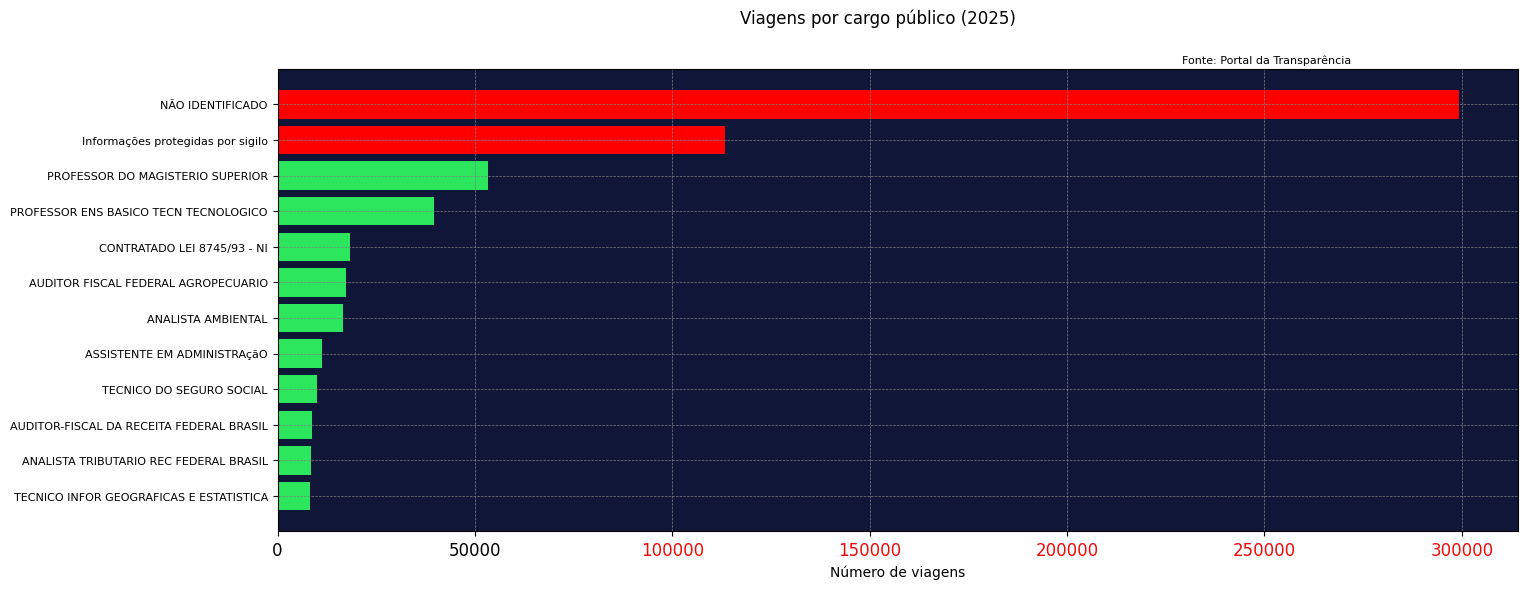

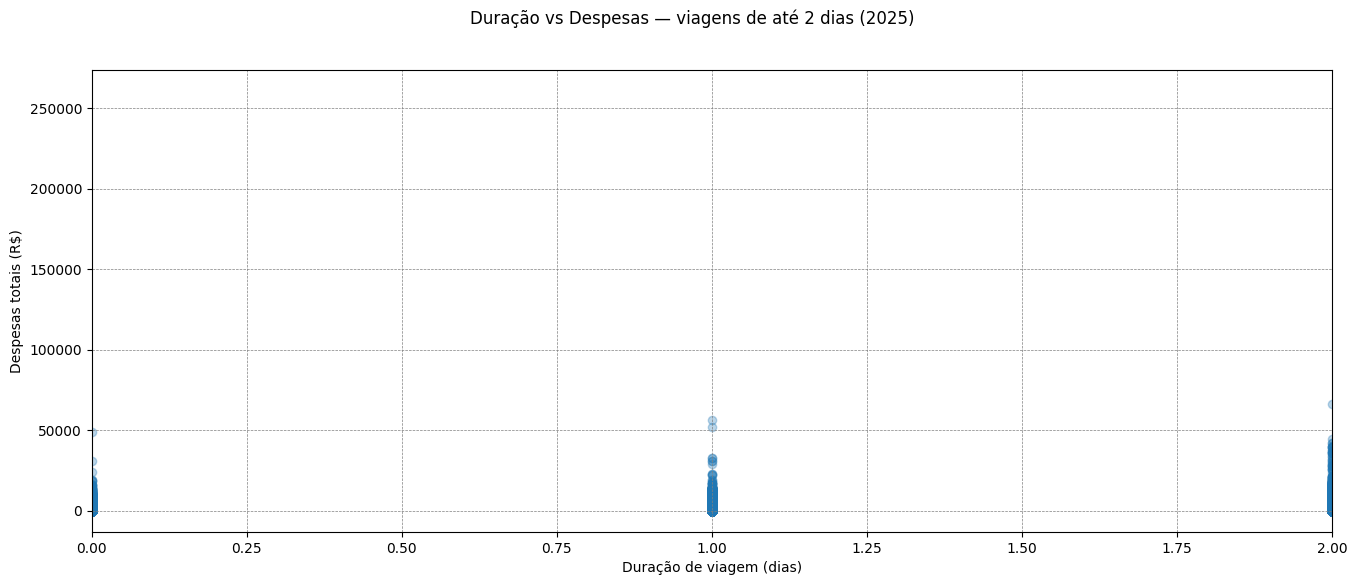

        Identificador do processo de viagem Número da Proposta (PCDP)  \
223930                             20961803                 000823/25   
588670                             21426671              024091/25-1C   

         Situação Viagem Urgente  \
223930  Realizada            SIM   
588670  Realizada            SIM   

                            Justificativa Urgência Viagem  \
223930        Trata-se do retorno do servidor á sua SEDE.   
588670  Não foi possível atender à exigência de prazo ...   

        Código do órgão superior    Nome do órgão superior  \
223930                     20000  Presidência da República   
588670                     25000     Ministério da Fazenda   

        Código órgão solicitante  \
223930                     20101   
588670                     25000   

                                   Nome órgão solicitante    CPF viajante  \
223930                           Presidência da República  ***.162.487-**   
588670  Ministério da Fazenda - Unida

In [ ]:
# ============================================================
# ANÁLISE DE VIAGENS - PORTAL DA TRANSPARÊNCIA (2025)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os
os.makedirs("/content/drive/MyDrive/AnaliseDados/output", exist_ok=True)

# ── Configurações gerais ─────────────────────────────────────
ano = 2025
caminho_dados          = f"/content/drive/MyDrive/AnaliseDados/{ano}_Viagem.csv"
caminho_dados_passagens = "/content/drive/MyDrive/AnaliseDados/2025_Passagem.csv"
caminho_saida_tabela   = f"/content/drive/MyDrive/AnaliseDados/output/tabela_{ano}.xlsx"
caminho_saida_grafico  = f"/content/drive/MyDrive/AnaliseDados/output/grafico_{ano}.png"
caminho_saida_scatter  = f"/content/drive/MyDrive/AnaliseDados/output/scatter_{ano}.png"

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


# ── 1. Leitura e limpeza dos dados ───────────────────────────
df_viagens = pd.read_csv(caminho_dados, encoding="Windows-1252", sep=";", decimal=",")

# Coluna de despesas totais
df_viagens['Despesas totais'] = (
    df_viagens['Valor diárias']
    + df_viagens['Valor outros gastos']
    + df_viagens['Valor passagens']
)

# Tratamento de nulos
df_viagens['Cargo'] = df_viagens['Cargo'].fillna('NÃO IDENTIFICADO')
df_viagens = df_viagens.fillna('NÃO IDENTIFICADO')

# Conversão de datas
df_viagens['Período - Data de início'] = pd.to_datetime(df_viagens['Período - Data de início'], format='%d/%m/%Y')
df_viagens['Período - Data de fim']    = pd.to_datetime(df_viagens['Período - Data de fim'],    format='%d/%m/%Y')

# Colunas derivadas
df_viagens['Mês da viagem']    = df_viagens['Período - Data de início'].dt.month_name()
df_viagens['Duração de viagem'] = (df_viagens['Período - Data de fim'] - df_viagens['Período - Data de início']).dt.days


# ── 2. Tabela consolidada por cargo ──────────────────────────
df_consolidado = (
    df_viagens
    .groupby('Cargo')
    .agg(
        Despesa_media           = ('Despesas totais',  'mean'),
        Duracao_media           = ('Duração de viagem', 'mean'),
        Despesas_totais         = ('Despesas totais',  'sum'),
        Destino_mais_frequente  = ('Destinos',          pd.Series.mode),
        n_viagens               = ('Nome',             'count')
    )
    .reset_index()
)

# Filtro: apenas cargos com mais de 1% das viagens
cargos_relevantes = (
    df_viagens['Cargo']
    .value_counts(normalize=True)
    .pipe(lambda s: s[s > 0.01].index)
)

df_final = (
    df_consolidado
    [df_consolidado['Cargo'].isin(cargos_relevantes)]
    .sort_values(by='n_viagens', ascending=False)
)


# ── 3. Gráfico de barras — viagens por cargo ─────────────────
fig, ax = plt.subplots(figsize=(16, 6))

cores = ['red' if v >= 100_000 else '#2ce65d' for v in df_final['n_viagens']]

ax.barh(df_final['Cargo'], df_final['n_viagens'], color=cores)
ax.invert_yaxis()
ax.set_facecolor('#101638')
ax.set_xlabel('Número de viagens')

fig.suptitle(f'Viagens por cargo público ({ano})')
plt.figtext(0.69, 0.89, 'Fonte: Portal da Transparência', fontsize=8, color='black')
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.yticks(fontsize=8)
plt.xticks(fontsize=12)

for label in ax.get_xticklabels():
    valor = int(label.get_text().replace(',', ''))
    label.set_color('#f00a0a' if valor >= 100_000 else 'black')

plt.savefig(caminho_saida_grafico, bbox_inches='tight')
plt.show()


# ── 4. Scatter — duração vs despesas totais ──────────────────
fig, ax = plt.subplots(figsize=(16, 6))

ax.scatter(df_viagens['Duração de viagem'], df_viagens['Despesas totais'], alpha=0.3)
ax.set_xlim(0, 2)
ax.set_xlabel('Duração de viagem (dias)')
ax.set_ylabel('Despesas totais (R$)')
fig.suptitle(f'Duração vs Despesas — viagens de até 2 dias ({ano})')
plt.grid(color='grey', linestyle='--', linewidth=0.5)

plt.savefig(caminho_saida_scatter, bbox_inches='tight')
plt.show()


# ── 5. Investigação de outliers ───────────────────────────────
filtro_valor_alto = df_viagens['Despesas totais'] > 50_000
filtro_curta      = df_viagens['Duração de viagem'] < 1.25

viagens_suspeitas = df_viagens[filtro_valor_alto & filtro_curta]
print(viagens_suspeitas)


# ── 6. Cruzamento com dados de passagens ─────────────────────
df_passagens = pd.read_csv(caminho_dados_passagens, encoding='Windows-1252', sep=';', decimal=',')

id_suspeito = 20961803
print(df_passagens[df_passagens['Identificador do processo de viagem'] == id_suspeito])


# ── 7. Exportação ─────────────────────────────────────────────
df_final.to_excel(caminho_saida_tabela, index=False)